# EXERCISE-Analyzing Data Science-Job Demand

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


df.head(2)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."


In [ ]:
df['Year'] = df['job_posted_date'].dt.year
df['Month'] = df['job_posted_date'].dt.month

In [7]:
df.head(2)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,Year,Month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN,2023,6
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr...",2023,1


job_country
United States     206292
India              51088
United Kingdom     40375
France             39922
Germany            27694
                   ...  
Guinea                 4
Lesotho                3
Mauritania             3
Bhutan                 3
Maldives               2
Name: count, Length: 160, dtype: int64

In [9]:
df_2023_USA = df[(df['Year'] == 2023) & (df['job_country'] == 'United States')]

In [17]:
df_2023_USA_pivot_table =  df_2023_USA.pivot_table(values='salary_year_avg', index = 'Month', columns = 'job_title_short', aggfunc='size')

In [18]:
Top_data_jobs_US = df['job_title_short'].value_counts().head(3).index

In [19]:
df_2023_USA_pivot_table = df_2023_USA_pivot_table[Top_data_jobs_US]
df_2023_USA_pivot_table

job_title_short,Data Analyst,Data Engineer,Data Scientist
Month,,,
1,8494,2655,6915
2,6124,3060,4956
3,6218,3183,4779
4,6049,2801,4867
5,4993,2976,4377
6,5683,2893,4645
7,5201,2570,4876
8,6634,3269,6318
9,4639,3224,4568


In [26]:
# Create a dictionary mapping numbers to month names
month_map = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

# Apply the map to overwrite your Month column (or create a new one)
df_2023_USA_pivot_table.index = df_2023_USA_pivot_table.index.map(month_map)

In [27]:
df_2023_USA_pivot_table = df_2023_USA_pivot_table[Top_data_jobs_US]
df_2023_USA_pivot_table

job_title_short,Data Analyst,Data Engineer,Data Scientist
Month,,,
January,8494,2655,6915
February,6124,3060,4956
March,6218,3183,4779
April,6049,2801,4867
May,4993,2976,4377
June,5683,2893,4645
July,5201,2570,4876
August,6634,3269,6318
September,4639,3224,4568


Text(0.5, 1.0, 'Monthly Job Postings for Top Data Jobs in the US')

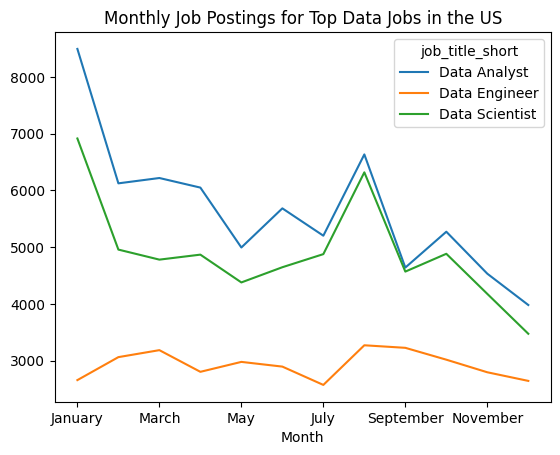

In [30]:
df_2023_USA_pivot_table.plot(kind='line')
plt.title('Monthly Job Postings for Top Data Jobs in the US')